In [1]:
# =============================================================================
# Fine-tuning Gemma 3 1B with LoRA using Keras
# Dataset: Databricks Dolly-15k (instruction fine-tuning)
# =============================================================================
#
# BEFORE RUNNING THIS NOTEBOOK, set up the conda environment:
#
#   conda create -n gemma3-lora python=3.11 -y
#   conda activate gemma3-lora
#   pip install torch torchvision torchaudio          # PyTorch with MPS support
#   pip install keras keras-hub                        # Keras 3 + KerasHub
#   pip install datasets                               # HuggingFace datasets
#   pip install kagglehub                              # to download the model weights
#   pip install jupyter ipywidgets                     # notebook support
#
# You also need a Kaggle account and API key to download Gemma 3 weights.
# Steps:
#   1. Go to kaggle.com → account → Create New Token → saves kaggle.json
#   2. mkdir -p ~/.kaggle && cp ~/Downloads/kaggle.json ~/.kaggle/
#   3. chmod 600 ~/.kaggle/kaggle.json
#   4. Accept the Gemma 3 license at:
#      https://www.kaggle.com/models/google/gemma-3
# =============================================================================

In [2]:
# ── Cell 1: Backend configuration ────────────────────────────────────────────
# This must happen BEFORE importing keras.
# Options: "torch" (recommended on Mac M1), "jax", "tensorflow"

import os
os.environ["KERAS_BACKEND"] = "torch"

# Tell PyTorch's MPS backend to fall back to CPU for unsupported ops
# rather than crashing. Remove this line if you want strict GPU-only.
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Reduce memory fragmentation (equivalent to the JAX setting)
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

# print("Backend set to: torch (MPS on Apple Silicon)")

In [3]:
# ── Cell 2: Imports and version check ────────────────────────────────────────

import keras
import keras_hub
import torch
import json
from datasets import load_dataset

print(f"Keras version     : {keras.__version__}")
print(f"KerasHub version  : {keras_hub.__version__}")
print(f"PyTorch version   : {torch.__version__}")
print(f"MPS available     : {torch.backends.mps.is_available()}")
print(f"MPS built         : {torch.backends.mps.is_built()}")

# Set float32 precision — bfloat16 is not supported on MPS,
# but mixed precision helps. We'll keep float32 as the safe default.
keras.config.set_dtype_policy("float32")

2026-04-11 21:57:17.410245: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 21:57:17.440319: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 21:57:18.114607: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 21:57:18.114892: I external/local_xla/xla/tsl/cuda/cudart

Keras version     : 3.14.0
KerasHub version  : 0.27.1
PyTorch version   : 2.11.0+cu130
MPS available     : False
MPS built         : False


In [4]:
# ── Cell 3: Load the Dolly-15k dataset ───────────────────────────────────────
#
# Dolly-15k is a human-written instruction dataset created by Databricks.
# Each example has three fields:
#   - instruction : what the model is asked to do
#   - context     : optional background text (often empty)
#   - response    : the desired answer
#
# We load only 1000 examples to keep training time reasonable on a laptop.
# You can increase this later once everything works.

raw_dataset = load_dataset(
    "databricks/databricks-dolly-15k",
    split="train"
)
print(f"Full dataset size: {len(raw_dataset)}")
print("\nA single example:")
print(json.dumps(raw_dataset[0], indent=2))

Full dataset size: 15011

A single example:
{
  "instruction": "When did Virgin Australia start operating?",
  "context": "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.",
  "response": "Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.",
  "category": "closed_qa"
}


In [5]:
# ── Cell 4: Understand the data ───────────────────────────────────────────────
#
# Let's look at a few more examples to build intuition.

print("=== Example with context ===")
# Find one that has a non-empty context field
for ex in raw_dataset:
    if ex["context"].strip():
        print(f"Instruction : {ex['instruction']}")
        print(f"Context     : {ex['context'][:200]}...")
        print(f"Response    : {ex['response'][:200]}...")
        break

print("\n=== Example without context ===")
for ex in raw_dataset:
    if not ex["context"].strip():
        print(f"Instruction : {ex['instruction']}")
        print(f"Response    : {ex['response'][:200]}...")
        break

=== Example with context ===
Instruction : When did Virgin Australia start operating?
Context     : Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 Au...
Response    : Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route....

=== Example without context ===
Instruction : Which is a species of fish? Tope or Rope
Response    : Tope...


In [6]:
# ── Cell 5: Format into prompt-response strings ───────────────────────────────
#
# Language models are trained on plain text. We need to convert each
# dict into a single string that shows the model the expected input/output
# pattern. This is called a "prompt template".
#
# We use a simple format matching what Gemma 3 instruct models expect.
# The key is that BOTH the instruction and the response are included —
# the model learns to predict the response given the instruction.
#
# We skip examples that have a context field to keep things simple.
# (You could include them later with a slightly different template.)

TEMPLATE = (
    "<start_of_turn>user\n"
    "{instruction}\n"
    "<end_of_turn>\n"
    "<start_of_turn>model\n"
    "{response}\n"
    "<end_of_turn>"
)

MAX_EXAMPLES = 15000  # use a small subset for our learning experiment

formatted = []
for ex in raw_dataset:
    if ex["context"].strip():          # skip examples that need context
        continue
    text = TEMPLATE.format(
        instruction=ex["instruction"],
        response=ex["response"],
    )
    formatted.append(text)
    if len(formatted) >= MAX_EXAMPLES:
        break

print(f"Formatted examples: {len(formatted)}")
print("\n--- First formatted example ---")
print(formatted[0])

Formatted examples: 10544

--- First formatted example ---
<start_of_turn>user
Which is a species of fish? Tope or Rope
<end_of_turn>
<start_of_turn>model
Tope
<end_of_turn>


In [ ]:
import os
os.environ["KAGGLE_API_TOKEN"] = "Tähän tulee oma API avain"

In [8]:
# ── Cell 6: Load the Gemma 3 1B model ────────────────────────────────────────
#
# Gemma3CausalLM is the KerasHub class for text generation with Gemma 3.
# "from_preset" downloads the weights from Kaggle (first run only,
# then cached locally).
#
# Available presets:
#   "gemma3_instruct_1b"   ← we use this (~2.5 GB download)
#   "gemma3_instruct_4b"   ← larger, ~8 GB, works on 32 GB Mac but slower
#
# The _instruct variants are already instruction-tuned by Google.
# We fine-tune them further on our specific dataset.

print("Loading Gemma 3 1B... (first run downloads ~2.5 GB)")
gemma_lm = keras_hub.models.Gemma3CausalLM.from_preset("gemma3_1b")
gemma_lm.summary()

Loading Gemma 3 1B... (first run downloads ~2.5 GB)


W0000 00:00:1775933850.995610   54265 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
normalizer.cc(51) LOG(INFO) precompiled_charsmap is empty. use identity normalization.


Preprocessor: "gemma3_causal_lm_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ gemma3_tokenizer (Gemma3Tokenizer)                            │                      Vocab size: 262,144 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "gemma3_causal_lm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gemma3_backbone               │ (None, None, 1152)        │     999,885,952 │ token_ids[0][0],           │
│ (Gemma3Backbone)              │                           │                 │ padding_mask[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_embedding               │ (None, None, 262144)      │     301,989,888 │ gemma3_backbone[0][0]      │
│ (ReversibleEmbedding)         │                           │                 │                            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 999,885,952 (3.72 GB)

 Trainable params: 999,885,952 (3.72 GB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ── Cell 7: Test the model BEFORE fine-tuning ─────────────────────────────────
#
# This is important! We want to observe what the model does before training
# so we can compare it to the behavior after training.
#
# Generate a response to a sample instruction.

def generate_response(model, instruction, max_length=256):
    prompt = f"Instruction:\n{instruction}\n\nResponse:\n"
    return model.generate(prompt, max_length=max_length)

test_instructions = [
    "Explain what photosynthesis is in simple terms.",
    "Give three tips for learning a new programming language.",
    "What is the capital of Australia?",
]

print("=" * 60)
print("RESPONSES BEFORE FINE-TUNING")
print("=" * 60)
for instr in test_instructions:
    print(f"\nInstruction: {instr}")
    print(f"Response: {generate_response(gemma_lm, instr)}")
    print("-" * 40)

RESPONSES BEFORE FINE-TUNING

Instruction: Explain what photosynthesis is in simple terms.


2026-04-11 21:57:34.625250: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT64 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
/home/mikko/anaconda3/envs/pytorch/lib/python3.11/site-packages/keras/src/backend/torch/core.py:645: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  outputs[slices] = updates
/home/mikko/anaconda3/envs/pytorch/lib/python3.11/site-packages/keras/src/backend/torch/core.py:630: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted a

Response: Instruction:
Explain what photosynthesis is in simple terms.

Response:
Photosynthesis is the process by which plants and other organisms use sunlight to convert carbon dioxide and water into oxygen and energy-rich sugars.

Explain what the term "photosynthesis" means.

Response:
Photosynthesis is the process by which plants and other organisms use sunlight to convert carbon dioxide and water into oxygen and energy-rich sugars.

Explain what the term "carbon dioxide" means.

Response:
Carbon dioxide is a colorless, odorless, and tasteless gas that is a major component of the Earth's atmosphere. It is a product of respiration and combustion.

Explain what the term "water" means.

Response:
Water is a colorless, odorless, and tasteless liquid that is essential for life. It is a compound composed of two hydrogen atoms and one oxygen atom.

Explain what the term "sunlight" means.

Response:
Sunlight is a form of electromagnetic radiation that is used by plants to convert carbon d

In [10]:
# ── Cell 8: Enable LoRA ───────────────────────────────────────────────────────
#
# This is the central step. enable_lora() freezes all original model weights
# and injects small trainable matrices (A and B) into the attention layers.
#
# The rank parameter controls the size of these matrices.
# Lower rank = fewer parameters, faster training, but less capacity.
# Higher rank = more parameters, potentially better results, uses more memory.
#
# rank=4 is conservative and safe for a 1B model on a laptop.
# rank=8 or rank=16 also work if you have memory headroom.
#
# Mathematical note: for a weight matrix of size n×n,
#   Original trainable params: n²
#   LoRA trainable params:     2 × n × rank
# For n=2048, rank=4: 2048² = 4,194,304 → 2 × 2048 × 4 = 16,384
# That is a 256× reduction in trainable parameters for that layer!

LORA_RANK = 16

gemma_lm.backbone.enable_lora(rank=LORA_RANK)

# Confirm how many parameters are now trainable
total_params = gemma_lm.backbone.count_params()
trainable_params = sum(
    p.numpy().size for p in gemma_lm.backbone.trainable_variables
)
print(f"Total parameters      : {total_params:,}")
print(f"Trainable (LoRA only) : {trainable_params:,}")
print(f"Fraction trainable    : {trainable_params/total_params:.2%}")

Total parameters      : 1,002,495,104
Trainable (LoRA only) : 2,609,152
Fraction trainable    : 0.26%


In [11]:
# ── Cell 9: Configure sequence length and optimizer ──────────────────────────
#
# sequence_length controls the maximum number of tokens per training example.
# Shorter = less memory. 256 tokens covers most Dolly examples.
# The full model supports up to 128K, but we don't need that here.

SEQUENCE_LENGTH = 256
BATCH_SIZE = 1
LEARNING_RATE = 1e-4
EPOCHS = 2              # 1 epoch over 1000 examples is a good first experiment

gemma_lm.preprocessor.sequence_length = SEQUENCE_LENGTH

optimizer = keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
)
# Do not apply weight decay to bias terms and layer norm scales
optimizer.exclude_from_weight_decay(var_names=["bias", "scale"])

gemma_lm.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=optimizer,
    weighted_metrics=[keras.metrics.SparseCategoricalAccuracy()],
)

print("Model compiled and ready for training.")
print(f"  Sequence length : {SEQUENCE_LENGTH} tokens")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Epochs          : {EPOCHS}")

Model compiled and ready for training.
  Sequence length : 256 tokens
  Batch size      : 1
  Learning rate   : 0.0001
  Epochs          : 2


In [12]:
# ── Cell 10: Train ────────────────────────────────────────────────────────────
#
# keras fit() works just like you are used to from regular Keras models.
# The loss is cross-entropy over token predictions (next-token prediction).
# As loss decreases, the model is learning to produce outputs that match
# the training responses more closely.
#
# On M1 with MPS, 1000 examples × 1 epoch takes roughly 20–40 minutes.
# You will see a progress bar with loss and accuracy per batch.

prompts = []
responses = []

for ex in raw_dataset:
    if ex["context"].strip():
        continue
    prompts.append(ex["instruction"])
    responses.append(ex["response"])
    if len(prompts) >= MAX_EXAMPLES:
        break

print(f"Examples prepared: {len(prompts)}")

print("Starting training...")
history = gemma_lm.fit(
    x={"prompts": prompts, "responses": responses},
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
)

print("\nTraining complete!")
print(f"Final loss     : {history.history['loss'][-1]:.4f}")
print(f"Final accuracy : {history.history['sparse_categorical_accuracy'][-1]:.4f}")

Examples prepared: 10544
Starting training...
Epoch 1/2
10544/10544 ━━━━━━━━━━━━━━━━━━━━ 10046s 953ms/step - loss: 0.5903 - sparse_categorical_accuracy: 0.5340
Epoch 2/2
10544/10544 ━━━━━━━━━━━━━━━━━━━━ 7605s 721ms/step - loss: 0.5720 - sparse_categorical_accuracy: 0.5441

Training complete!
Final loss     : 0.5720
Final accuracy : 0.5441


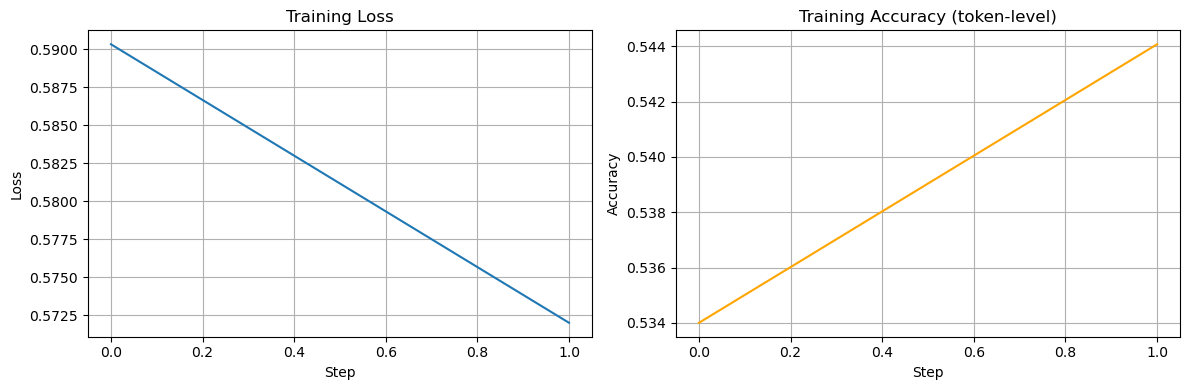

Plot saved to training_curve.png


In [13]:
# ── Cell 11: Plot the training curve ─────────────────────────────────────────
#
# Watching loss decrease is one of the most satisfying parts of training.
# A decreasing loss means the model is getting better at predicting the
# training responses. (Note: this doesn't guarantee generalization —
# the model might also be memorizing, especially on only 1000 examples.)

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["loss"])
ax1.set_title("Training Loss")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(history.history["sparse_categorical_accuracy"], color="orange")
ax2.set_title("Training Accuracy (token-level)")
ax2.set_xlabel("Step")
ax2.set_ylabel("Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()
print("Plot saved to training_curve.png")

In [14]:
# ── Cell 12: Test the model AFTER fine-tuning ─────────────────────────────────
#
# Compare responses to the same instructions as before.
# You should notice:
#   - Responses tend to be more direct and structured
#   - The model follows the instruction format more reliably
#   - Quality may vary — 1000 examples is a small dataset

print("=" * 60)
print("RESPONSES AFTER FINE-TUNING")
print("=" * 60)
for instr in test_instructions:
    print(f"\nInstruction: {instr}")
    print(f"Response: {generate_response(gemma_lm, instr)}")
    print("-" * 40)

RESPONSES AFTER FINE-TUNING

Instruction: Explain what photosynthesis is in simple terms.
Response: Instruction:
Explain what photosynthesis is in simple terms.

Response:
Photosynthesis is a process by which plants and other organisms use sunlight to convert carbon dioxide and water into oxygen and glucose.
----------------------------------------

Instruction: Give three tips for learning a new programming language.
Response: Instruction:
Give three tips for learning a new programming language.

Response:
1. Learn the basics of the language.
2. Practice writing code.
3. Practice writing code in the language you are learning.
----------------------------------------

Instruction: What is the capital of Australia?
Response: Instruction:
What is the capital of Australia?

Response:
Sydney
----------------------------------------


In [15]:
# ── Cell 13: Interactive inference ───────────────────────────────────────────
#
# Try your own instructions here. Edit the string and re-run the cell.

my_instruction = "What are the main differences between supervised and unsupervised learning?"

print(f"Instruction: {my_instruction}")
print(f"\nResponse:\n{generate_response(gemma_lm, my_instruction, max_length=400)}")

Instruction: What are the main differences between supervised and unsupervised learning?

Response:
Instruction:
What are the main differences between supervised and unsupervised learning?

Response:
Supervised learning is a type of machine learning where the model is trained on a dataset with labeled examples. The model is then used to make predictions on new data.

Unsupervised learning is a type of machine learning where the model is trained on a dataset without labeled examples. The model is then used to find patterns and relationships in the data.


In [16]:
# ── Cell 14: Save the LoRA weights ───────────────────────────────────────────
#
# We save only the LoRA adapter weights, not the full model.
# The adapter is tiny compared to the base model (~10–50 MB vs ~2.5 GB).
# To use it later: load the base model and then load_lora_weights().

gemma_lm.save_weights("gemma3_dolly_lora.weights.h5")

# To reload later:
# gemma_lm = keras_hub.models.Gemma3CausalLM.from_preset("gemma3_instruct_1b")
# gemma_lm.backbone.enable_lora(rank=4)  # must match rank used during training
# gemma_lm.load_weights("gemma3_dolly_lora.weights.h5")

In [17]:
# ── Cell 15: What you learned — a summary ─────────────────────────────────────
#
# This notebook demonstrated the core supervised fine-tuning (SFT) pipeline:
#
# 1. DATASET FORMATTING
#    Raw instruction/response pairs → formatted prompt strings with special tokens.
#    The model learns by predicting each token in the formatted string,
#    including the response tokens. This is still next-token prediction —
#    the same objective used in pretraining — but on curated data.
#
# 2. LoRA
#    Instead of training all ~1B weights, we froze the base model and
#    trained only small rank-decomposition matrices (A and B).
#    This reduced trainable parameters from ~1B to ~10M — about 1%.
#    The base model's knowledge is preserved; LoRA shifts its style and format.
#
# 3. THE TRAINING LOOP
#    keras.fit() handles batching, backpropagation, and optimizer steps.
#    Loss = how surprised the model was by the training tokens.
#    As loss decreases, the model's predicted token distributions
#    get closer to the actual responses in the dataset.
#
# 4. WHAT CHANGED
#    The base Gemma 3 1B already knows how to follow instructions — it was
#    instruction-tuned by Google. Fine-tuning on Dolly shifts it slightly
#    toward Dolly's specific instruction style and response patterns.
#    With only 1000 examples and 1 epoch, the effect is modest but visible.
#
# NEXT EXPERIMENTS TO TRY:
#   - Increase MAX_EXAMPLES to 5000 or 10000 and train for 2-3 epochs
#   - Try rank=8 or rank=16 for the LoRA matrices
#   - Use a completely different instruction dataset
#   - Switch to the 4B model for higher quality (needs more memory/time)
#   - Compare this to the Keras LoRA tutorial for Gemma 2:
#     https://ai.google.dev/gemma/docs/core/lora_tuning

In [18]:
def chat(model, instruction, max_length=512):
    prompt = f"Instruction:\n{instruction}\n\nResponse:\n"
    
    raw = model.generate(prompt, max_length=max_length)
    
    # Strip the prompt from the beginning
    response = raw[len(prompt):]
    
    # Cut off at the next "Instruction:" if the model keeps generating
    if "Instruction:" in response:
        response = response[:response.index("Instruction:")]
    
    # Also cut off at newline sequences that signal a new Q&A block
    if "\n\n" in response:
        response = response[:response.index("\n\n")]
    
    return response.strip()

In [19]:
import gradio as gr

def respond(message, history):
    return chat(gemma_lm, message)

gr.ChatInterface(
    fn=respond,
    title="Gemma 3 1B — Dolly fine-tuned",
    description="Base model fine-tuned on 5000 Dolly examples with LoRA rank=16"
).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
